In [230]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)

params = Params(
    model_name="WindyRoomsNegative",
    n_runs=3,
    n_episodes=15_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=32,
    alpha=0.8,
    gamma=0.99,
    epsilon=0.15,
    kappa=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(
    params.model_name,# render_mode="human",
    # rewards={"step":0,"fail":-1,"goal":1}
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = "results/results/online_"+params.model_name

In [231]:
table_of = QR(params).train(env, explorer, scheduler)

100%|██████████| 45000/45000 [04:10<00:00, 179.66it/s, run=3, t=15000]


In [185]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(rng)

returns = MonteCarlo(env, policy, params.gamma, total_episodes=50_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 50000/50000 [00:08<00:00, 5881.66it/s]


In [ ]:
scheduler = get_exp_scheduler(params.alpha, 2000, min_val=0.00025)

# table_off = QR(params).train(env, explorer, scheduler)
table_off2 = QR(params).train(env, explorer, scheduler)

100%|██████████| 30000/30000 [40:18<00:00, 12.41it/s, run=2, t=15000] 


In [218]:
from pathlib import Path
import datetime
import json

def save_experiment(tables_run, params, save_to="experiments", name=None):
    timestamp = datetime.datetime.now().strftime("%d%m_%H%M")
    exp_dir = Path(f"{save_to}/{params.model_name}_{timestamp if name is None else name}")
    exp_dir.mkdir(parents=True, exist_ok=True)

    np.savez(exp_dir / "tables.npz", tables=tables_run)
    with open(exp_dir / "params.json", "w") as f:
        json.dump(params._asdict(), f, indent=4)


def load_experiment(experiment_name=None):
    if experiment_name is None:
        import os
        experiments_dir = "experiments/"
        experiment_name = max(
            (d for d in os.listdir(experiments_dir) if os.path.isdir(os.path.join(experiments_dir, d))),
            key=lambda d: os.path.getctime(os.path.join(experiments_dir, d))
        )
    
    exp_dir = Path(f"{experiment_name}")
    params = Params(**json.load(open(exp_dir / "params.json", "r")))
    
    tables_file = exp_dir / "tables.npz"
    tables = np.load(tables_file)["tables"]
    return tables, params

In [213]:
table_off_final = np.concatenate((table_off2, table_off))

In [221]:
a,b= load_experiment("results/results/online_WindyRooms/WindyRooms_0312_1331")

In [54]:
# # plot_map((table_off[0,-1].mean(-1) - np.tile(V_pi[:, None], (1, 4)))**2, params, False)
# # plot_map(np.tile(V_pi[:, None], (1, 4)), params)

# vals = (table_off[0,-1].mean(-1) - np.tile(V_pi[:, None], (1, 4)))

# plot_map(vals, params)

In [199]:
scheduler = get_exp_scheduler(params.alpha, 2000, min_val=0.00025)

# table_off = QR(params).train(env, explorer, scheduler)
table_on = QR(params, policy).train(env, explorer, scheduler)
# table1 = QR(params._replace(kappa=1.0), policy).train(env, explorer, scheduler)
# qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 45000/45000 [01:51<00:00, 403.20it/s, run=3, t=15000]


In [226]:
save_experiment(table_on, params, save_to=save_to, name="offline windyrooms")

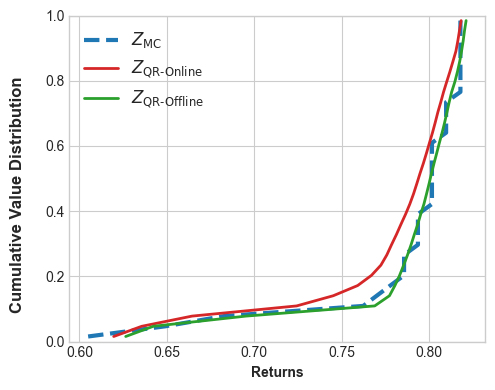

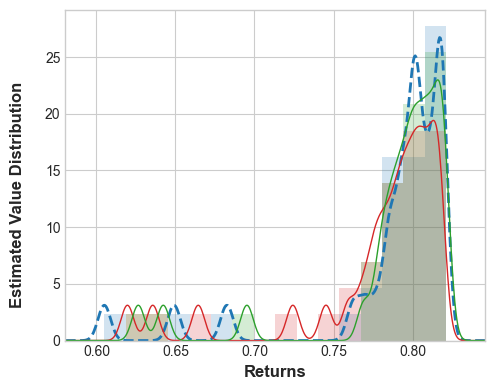

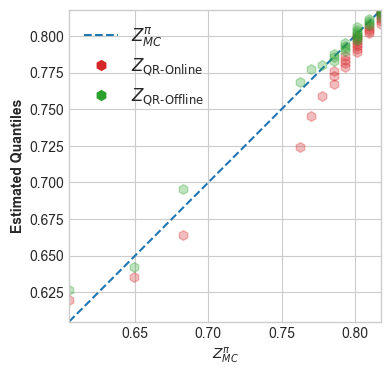

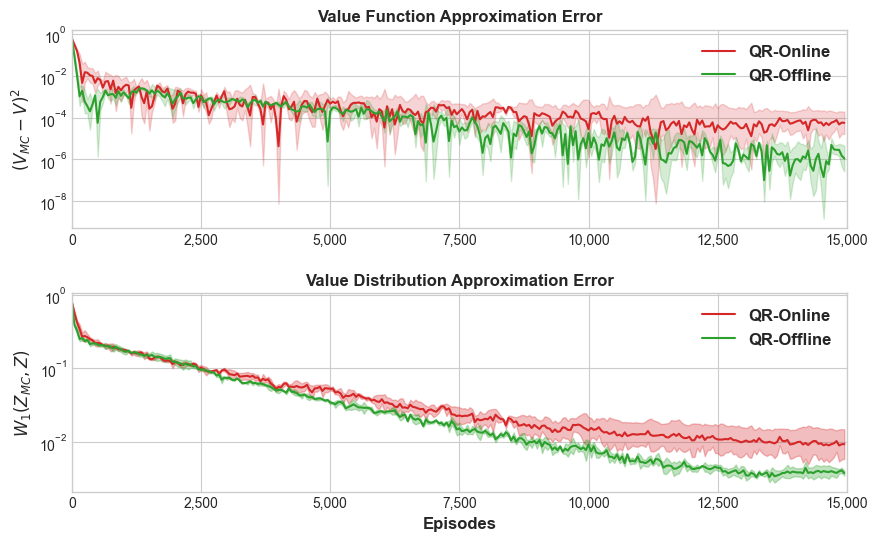

In [229]:
def get_q(table): return table[:,:,s_init,policy[s_init].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    # (get_best(table_off2), r"$Z_{\text{QR-0}}$"),
    (get_best(table_off_final), r"$Z_{\text{QR-Online}}$"),
    (get_best(table_on), r"$Z_{\text{QR-Offline}}$"),
    # (get_best(table1), r"$Z_{\text{QR-1}}$"),
]
plot_qs = [
    # (get_q(table_off2), "QR-0"),
    (get_q(table_off_final), "QR-Online"),
    (get_q(table_on), "QR-Offline"),
    # (get_q(table1), "QR-1"),
    # (get_q(qtable), "Q-learning"),
]
LOW_BANDWIDTH = 0.004
bw = LOW_BANDWIDTH

plot_cdf(plot_objs, tau_returns, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{MC}}$")
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, linewidth=1.0, N=params.N//2, hist_alpha=0.2, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to, alpha=0.3, markersize=7, lims=(tau_returns.min(), tau_returns.max()))
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3], true_dist="{MC}")

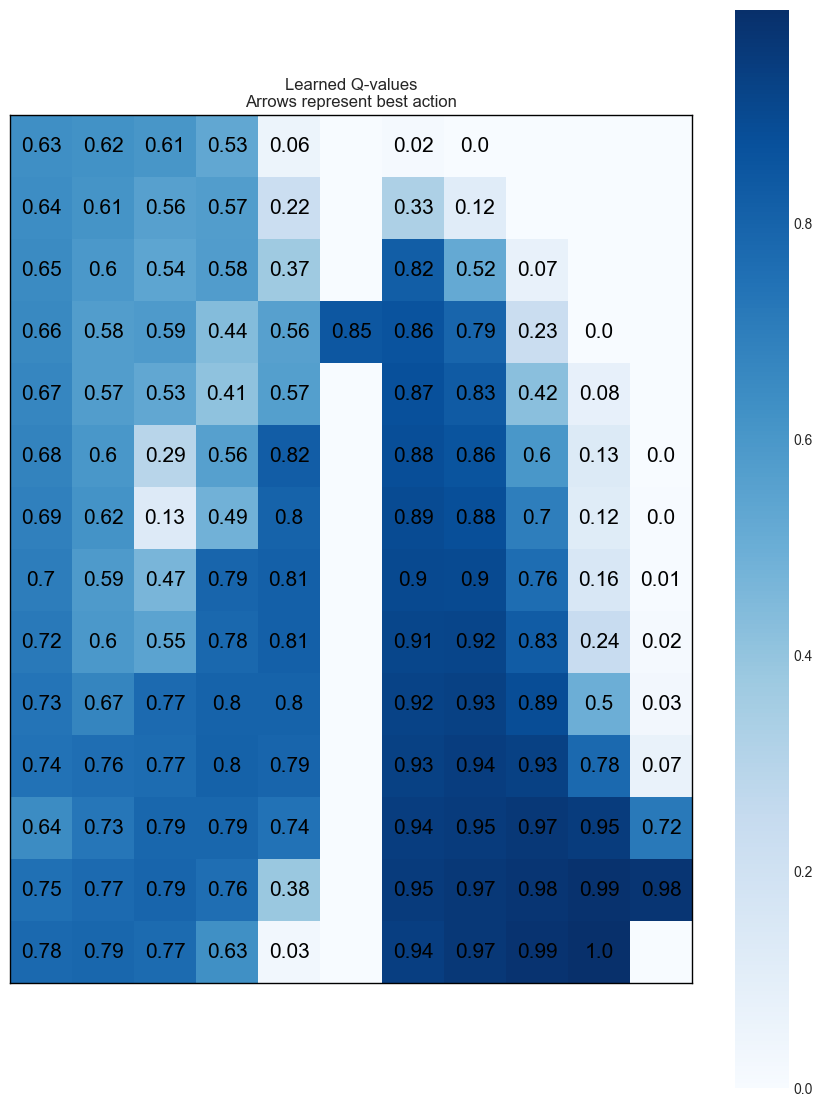

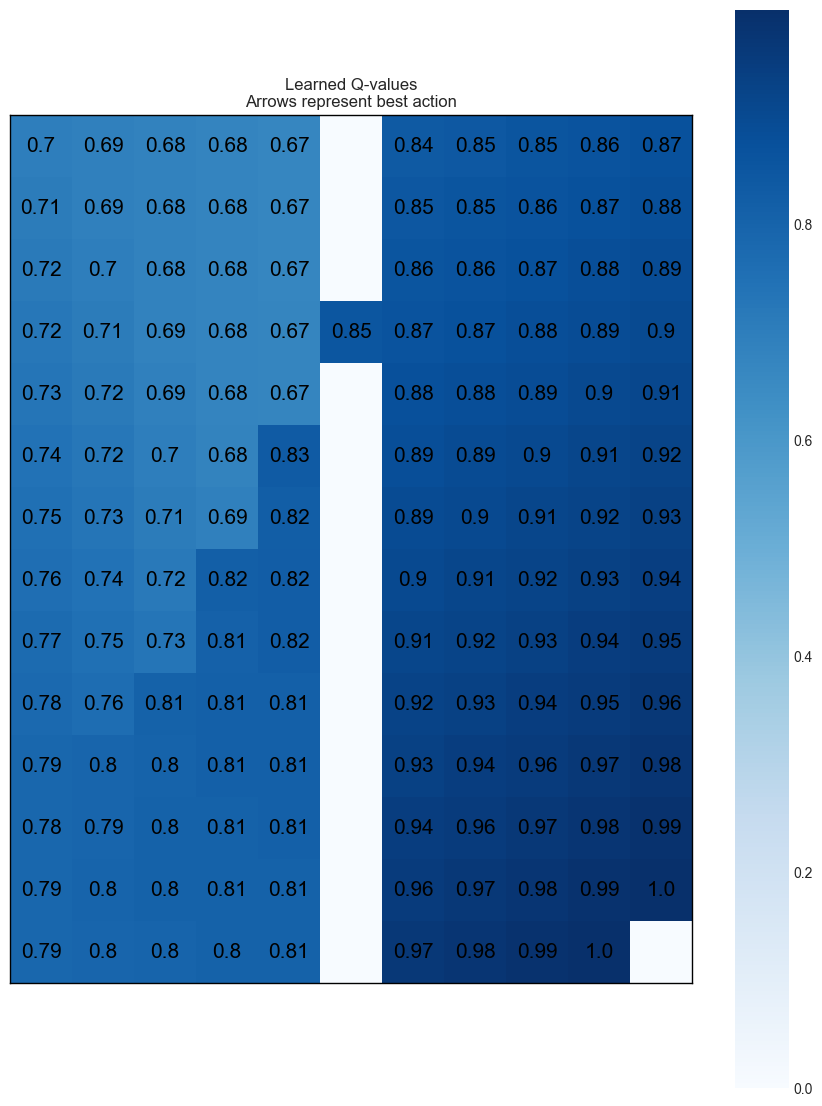

In [50]:
plot_map(table0.mean((0,-1))[-1], params)
plot_map(np.tile(V_pi[:, None], (1, 4)), params, V=V_pi)

In [ ]:
tables_mc = np.zeros((params.nS, 1000))
for s in range(params.nS):
    if env.unwrapped._is_terminal.flatten()[s]:
        tables_mc[s] = np.zeros(1000)
    else:
        tables_mc[s] = MonteCarlo(env, policy, params.gamma, s_init=s, total_episodes=1000)

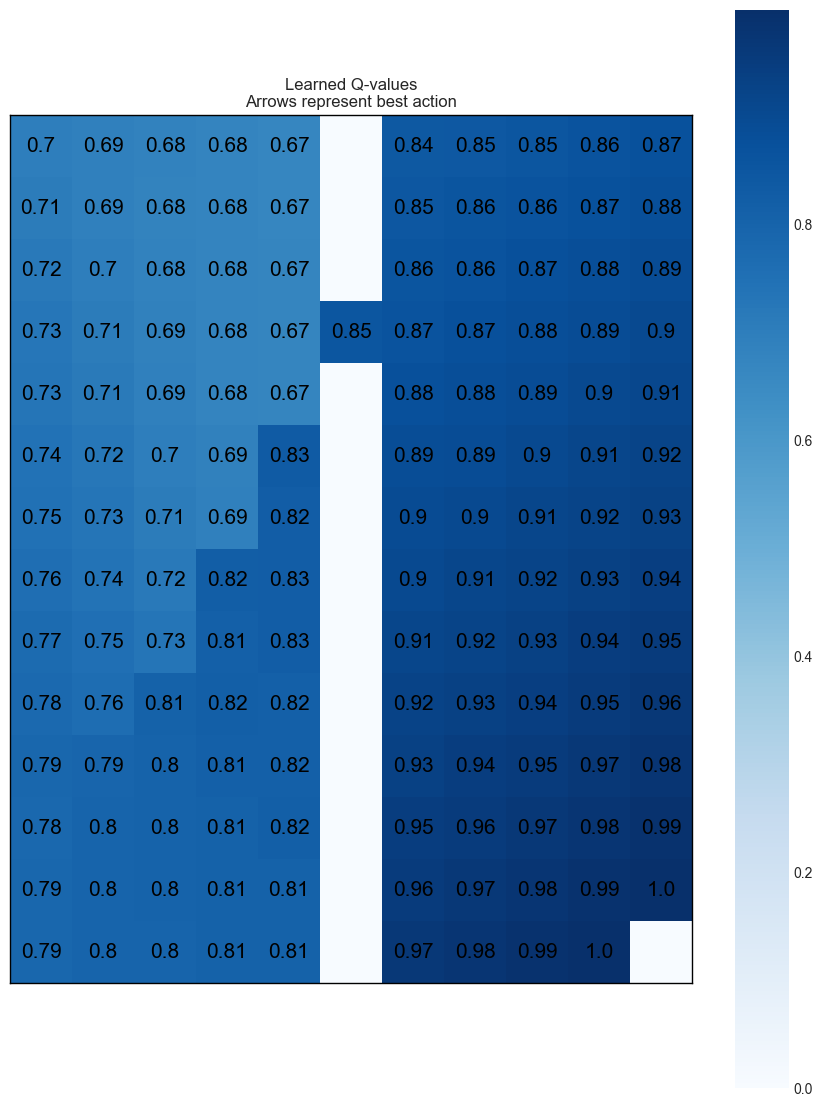

In [61]:
plot_map(np.tile(tables_mc.mean(1)[:, None], (1, 4)), params)